<a href="https://colab.research.google.com/github/KuzotenShi/Trabajo_final/blob/main/Modelo_de_Machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Modelo de Machine learning EDA Steam

In [ ]:
import pandas as pd
import gdown
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

Carga de Doc

In [ ]:
url = 'https://drive.google.com/uc?id=1W-8v37Z1WLOWZBn9G4sqBbSRpcVo1Qwa'

gdown.download(url, 'steam_games_procesado_final.csv', quiet=False)



Downloading...
From (original): https://drive.google.com/uc?id=1W-8v37Z1WLOWZBn9G4sqBbSRpcVo1Qwa
From (redirected): https://drive.google.com/uc?id=1W-8v37Z1WLOWZBn9G4sqBbSRpcVo1Qwa&confirm=t&uuid=6651f1f5-28c2-4e91-bcd1-e4ba8d0c8e99
To: /content/steam_games_procesado_final.csv
100%|██████████| 217M/217M [00:03<00:00, 58.1MB/s]


'steam_games_procesado_final.csv'

In [ ]:
df = pd.read_csv('steam_games_procesado_final.csv')

In [ ]:
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Tags,Estimated owners agrupado,Rango_Precio,Horas_Juego,Rango_Tiempo,Total_Reviews,Approval_Rate,Price_Group,Platform_Combo,Tiene_Descuento
0,1635980,Kubinashi Recollection,2021-12-08,0 - 20000,0.0,0,11.99,0.0,1.0,"In order to retrieve the lost memories, Sekiba...",...,"Action,Puzzle,Faith,Cute,Pixel Graphics,Fantas...",0,$10-$20,0.000000,0 hrs,171.0,95.321637,Estándar ($5-$15),Solo Windows,Sin Descuento
1,3337970,Coffee Beans,2024-11-22,0 - 20000,0.0,0,0.69,0.0,0.0,Coffee Beans A fun and challenging Match 3 Typ...,...,"Casual,Puzzle,Clicker,2D,Capitalism,Physics,In...",0,$0-$10,0.000000,0 hrs,2.0,50.000000,Económico (<$5),Solo Windows,Sin Descuento
2,1470270,Powerboat VR,2020-12-29,0 - 20000,0.0,0,18.99,0.0,0.0,Please note that this is an EARLY ACCESS game ...,...,"Exploration,Driving,Naval,Transportation,Manag...",0,$10-$20,0.000000,0 hrs,22.0,72.727273,Medio ($15-$30),Solo Windows,Sin Descuento
3,682780,Breaking Good,2017-08-04,20000 - 50000,0.0,0,2.00,0.0,0.0,As many of you are wondering how the game work...,...,"Education,Science,Casual,Match 3,Relaxing,Puzz...",0 - 100.000,$0-$10,1.716667,0 - 2 hrs,157.0,88.535032,Económico (<$5),Multiplataforma Total (Win+Mac+Lin),Sin Descuento
4,3674050,Silly's Gameshow,2025-06-06,0 - 0,0.0,0,0.00,0.0,0.0,Silly's Gameshow is a co-op horror game where ...,...,Sin Registros,0,Gratis ($0),0.000000,0 hrs,0.0,NaN,Gratis ($0),Solo Windows,Sin Descuento


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115289 entries, 0 to 115288
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       115289 non-null  int64  
 1   Name                        115289 non-null  object 
 2   Release date                115289 non-null  object 
 3   Estimated owners            115289 non-null  object 
 4   Peak CCU                    115289 non-null  float64
 5   Required age                115289 non-null  int64  
 6   Price                       115289 non-null  float64
 7   Discount                    115289 non-null  float64
 8   DLC count                   115289 non-null  float64
 9   About the game              115289 non-null  object 
 10  Supported languages         115289 non-null  object 
 11  Full audio languages        115289 non-null  object 
 12  Windows                     115289 non-null  bool   
 13  Mac           

Variables que se van
- fecha de salida
- del 9 al 11 se van
- 17 al 20 se van
de las medias usar 21 y 23 (22 y 24 se van)
- 25, 26 y 29 se van
- 37

In [ ]:
df.drop(columns=['Release date','AppID', 'Name', 'About the game', 'Supported languages', 'Approval_Rate','Full audio languages', 'Positive', 'Negative', 'Achievements', 'Recommendations', 'Average playtime two weeks', 'Median playtime two weeks', 'Developers', 'Publishers', 'Tags', 'Platform_Combo'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115289 entries, 0 to 115288
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Estimated owners           115289 non-null  object 
 1   Peak CCU                   115289 non-null  float64
 2   Required age               115289 non-null  int64  
 3   Price                      115289 non-null  float64
 4   Discount                   115289 non-null  float64
 5   DLC count                  115289 non-null  float64
 6   Windows                    115289 non-null  bool   
 7   Mac                        115289 non-null  bool   
 8   Linux                      115289 non-null  bool   
 9   Metacritic score           115289 non-null  float64
 10  User score                 115289 non-null  float64
 11  Average playtime forever   115289 non-null  float64
 12  Median playtime forever    115289 non-null  float64
 13  Categories                 11

Patron de faltantes

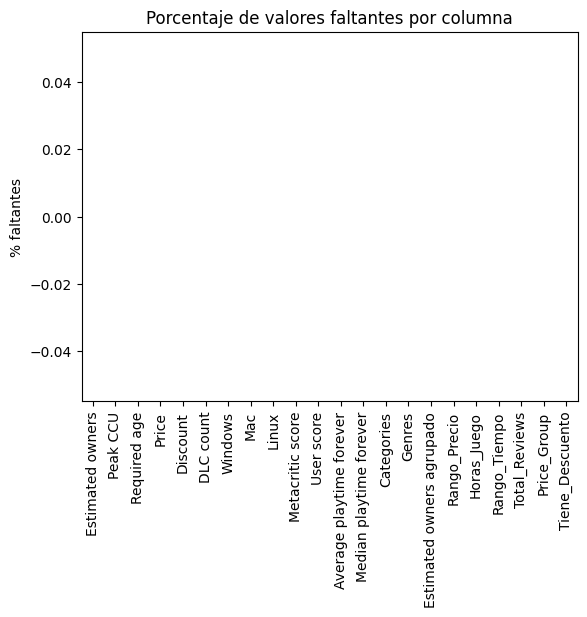

In [ ]:
df_missing = df.copy()
missing_pct = (df_missing.isna().mean() * 100).sort_values(ascending=False)
missing_pct.plot(kind='bar')
plt.title('Porcentaje de valores faltantes por columna')
plt.ylabel('% faltantes')
plt.show()

##Idea del modelo
Predecir si un juego tendrá un número alto de propietarios (Estimated owners agrupado o crear una variable binaria como Éxito Commercial basado en tener más de X copias vendidas o Price_Group).
la forma en la que este se va a realizar es primero definiendo la variable de exito y para esto hay que definir Éxito_Comercial = 1 si supera el nivel básico de ventas.

In [ ]:
de_exito = ['20000 - 50000', '50000 - 100000', '100000 - 200000',
            '200000 - 500000', '500000 - 1000000', '1000000 - 2000000',
            '2000000 - 5000000', '5000000 - 10000000', '10000000 - 20000000',
            '20000000 - 50000000', '50000000 - 100000000', '100000000 - 200000000']

df['Éxito_Comercial'] = df['Estimated owners'].isin(de_exito).astype(int)

# Inspección del balance de clases
print("Distribución de la variable objetivo:")
print(df['Éxito_Comercial'].value_counts(normalize=True))


Distribución de la variable objetivo:
Éxito_Comercial
0    0.783926
1    0.216074
Name: proportion, dtype: float64


2. Selección de características (X) y objetivo (y)

In [ ]:
cols_no_deseadas = ['AppID', 'Name', 'Categories', 'Genres', 'Estimated owners', 'Éxito_Comercial']
X = df.drop(columns=[c for c in cols_no_deseadas if c in df.columns])
y = df['Éxito_Comercial']

# Separación de variables

In [ ]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Numéricas ({len(num_cols)}): {num_cols}")
print(f"Categóricas ({len(cat_cols)}): {cat_cols}")

Numéricas (11): ['Peak CCU', 'Required age', 'Price', 'Discount', 'DLC count', 'Metacritic score', 'User score', 'Average playtime forever', 'Median playtime forever', 'Horas_Juego', 'Total_Reviews']
Categóricas (8): ['Windows', 'Mac', 'Linux', 'Estimated owners agrupado', 'Rango_Precio', 'Rango_Tiempo', 'Price_Group', 'Tiene_Descuento']


#Plan de Preprocesamiento y Separación de Datos (Train / Test)


Para el entrenamiento de datos vamos a usar 80% en entrenamiento 20% en test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

Pipelines

In [ ]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=20))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [ ]:
print("Preprocesando datos...")
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"¡Hecho! Dimensión de X_train_prep: {X_train_prep.shape}")
print(f"Dimensión de X_test_prep: {X_test_prep.shape}")

Preprocesando datos...
¡Hecho! Dimensión de X_train_prep: (92231, 44)
Dimensión de X_test_prep: (23058, 44)


#Creacion y evaluacion de los 10 modelos

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

modelos = {
    "Modelo 1: RegLog (C=0.01, L2, lbfgs)": LogisticRegression(C=0.01, penalty='l2', solver='lbfgs', max_iter=500, random_state=42),
    "Modelo 2: RegLog (C=0.1, L2, lbfgs)": LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', max_iter=500, random_state=42),
    "Modelo 3: RegLog (C=1.0, L2, lbfgs - Default)": LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=500, random_state=42),
    "Modelo 4: RegLog (C=10.0, L2, lbfgs)": LogisticRegression(C=10.0, penalty='l2', solver='lbfgs', max_iter=500, random_state=42),
    "Modelo 5: RegLog (C=0.01, L1, liblinear)": LogisticRegression(C=0.01, penalty='l1', solver='liblinear', max_iter=500, random_state=42),
    "Modelo 6: RegLog (C=0.1, L1, liblinear)": LogisticRegression(C=0.1, penalty='l1', solver='liblinear', max_iter=500, random_state=42),
    "Modelo 7: RegLog (C=1.0, L1, liblinear)": LogisticRegression(C=1.0, penalty='l1', solver='liblinear', max_iter=500, random_state=42),
    "Modelo 8: RegLog (C=10.0, L1, liblinear)": LogisticRegression(C=10.0, penalty='l1', solver='liblinear', max_iter=500, random_state=42),
    "Modelo 9: RegLog (C=100.0, L2, lbfgs)": LogisticRegression(C=100.0, penalty='l2', solver='lbfgs', max_iter=500, random_state=42),
    "Modelo 10: RegLog (Sin Regularización, lbfgs)": LogisticRegression(penalty=None, solver='lbfgs', max_iter=500, random_state=42)
}



Entrenamiento y evaluacion de los modelos, para esto se van a utiizar los resultados de los 10 modelos y se clasificaran segun el F1 score.

In [ ]:
resultados = []

print("Entrenando y evaluando las 10 variantes de Regresión Logística...")
for nombre, modelo in modelos.items():
    # Entrenar modelo
    modelo.fit(X_train_prep, y_train)

    # Predecir clases y probabilidades
    y_pred = modelo.predict(X_test_prep)
    y_proba = modelo.predict_proba(X_test_prep)[:, 1]

    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    # Guardar resultados
    resultados.append({
        "Modelo": nombre,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4)
    })

df_resultados = pd.DataFrame(resultados).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
df_resultados

Entrenando y evaluando las 10 variantes de Regresión Logística...


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,"Modelo 5: RegLog (C=0.01, L1, liblinear)",1.0,1.0000,1.0,1.0000,1.0000
1,"Modelo 4: RegLog (C=10.0, L2, lbfgs)",1.0,1.0000,1.0,1.0000,1.0000
2,"Modelo 9: RegLog (C=100.0, L2, lbfgs)",1.0,1.0000,1.0,1.0000,1.0000
3,"Modelo 10: RegLog (Sin Regularización, lbfgs)",1.0,1.0000,1.0,1.0000,1.0000
4,"Modelo 6: RegLog (C=0.1, L1, liblinear)",1.0,1.0000,1.0,1.0000,1.0000
5,"Modelo 1: RegLog (C=0.01, L2, lbfgs)",1.0,0.9998,1.0,0.9999,0.9999
6,"Modelo 2: RegLog (C=0.1, L2, lbfgs)",1.0,0.9998,1.0,0.9999,1.0000
7,"Modelo 3: RegLog (C=1.0, L2, lbfgs - Default)",1.0,0.9998,1.0,0.9999,0.9999
8,"Modelo 8: RegLog (C=10.0, L1, liblinear)",1.0,0.9998,1.0,0.9999,0.9999
9,"Modelo 7: RegLog (C=1.0, L1, liblinear)",1.0,0.9998,1.0,0.9999,1.0000


#Vista grafica

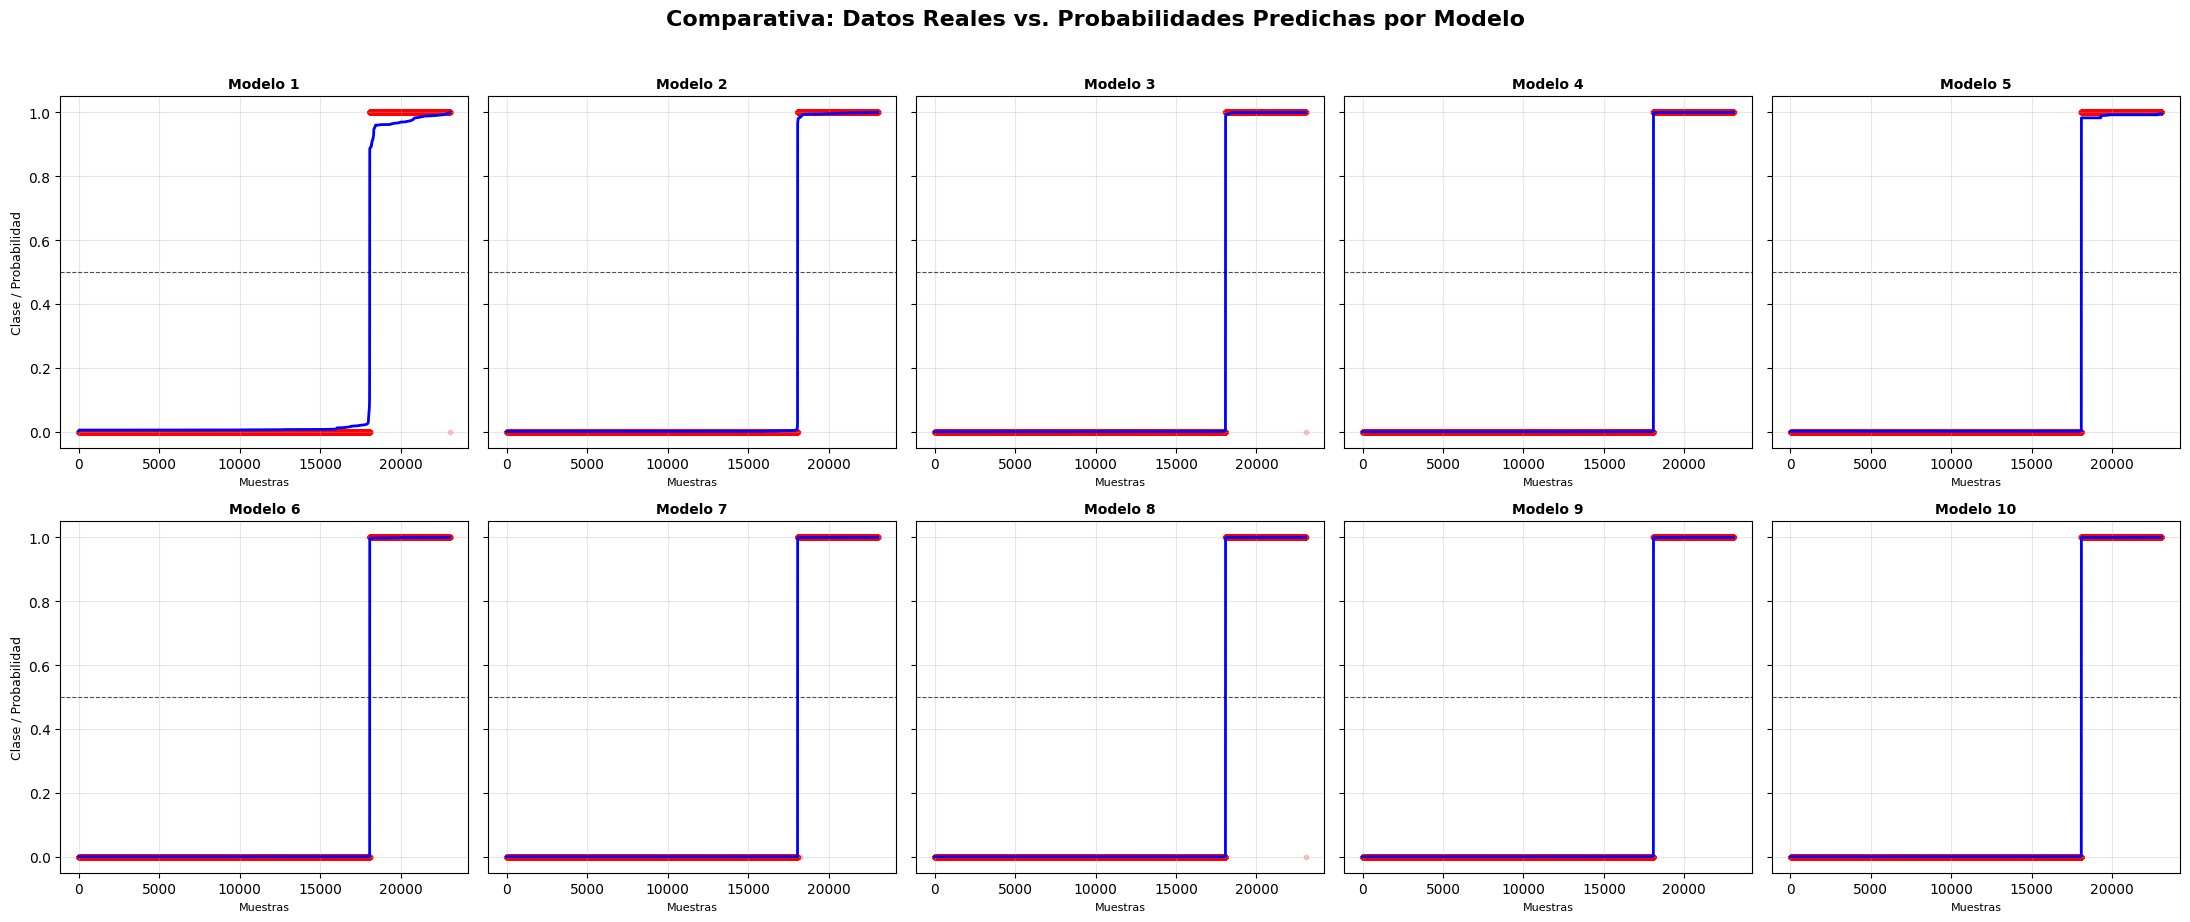

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9), sharey=True)
axes = axes.flatten()

for i, (nombre, modelo) in enumerate(modelos.items()):
    y_proba = modelo.predict_proba(X_test_prep)[:, 1]


    indices_ordenados = np.argsort(y_proba)
    y_real_ordenado = y_test.iloc[indices_ordenados].values
    y_proba_ordenada = y_proba[indices_ordenados]
    ax = axes[i]

    # Puntos reales (rojo)
    ax.scatter(
        range(len(y_real_ordenado)),
        y_real_ordenado,
        color='red',
        alpha=0.2,
        s=10,
        label='Real'
    )

    # Curva de predicción del modelo (azul)
    ax.plot(
        range(len(y_proba_ordenada)),
        y_proba_ordenada,
        color='blue',
        linewidth=2,
        label='Predicción'
    )

    # Umbral de decisión (0.5)
    ax.axhline(y=0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

    etiqueta_corta = nombre.split(':')[0]
    ax.set_title(f"{etiqueta_corta}", fontsize=10, fontweight='bold')
    ax.set_xlabel('Muestras', fontsize=8)
    if i % 5 == 0:
        ax.set_ylabel('Clase / Probabilidad', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'Comparativa: Datos Reales vs. Probabilidades Predichas por Modelo',
    fontsize=16,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.show()

#Análisis de Resultados y Selección del Modelo Ganador
Tras evaluar las 10 variantes de Regresión Logística, se observa un desempeño sobresaliente en todas las configuraciones, obteniendo métricas de Accuracy, Precision, Recall, F1-Score y ROC-AUC superiores al $0.9999$. El Modelo 5 (RegLog con $C=0.01$, penalización L1 y solver liblinear) se posiciona en el primer lugar al lograr una puntuación perfecta de $1.0000$ en todas las métricas de evaluación dentro del conjunto de prueba.

#¿Por qué gana el Modelo 5?
La razón principal de su victoria frente a las demás variantes radica en el uso de la regularización Lasso (L1) combinada con un valor bajo de $C$ ($0.01$). La penalización L1 actúa como un selector automático de características al forzar a cero los coeficientes de las variables menos relevantes o redundantes. Al aplicar una fuerte regularización ($C=0.01$), el Modelo 5 no solo logra una clasificación perfecta, sino que lo hace construyendo la arquitectura más simple, liviana y menos propensa al sobreajuste (overfitting), simplificando el espacio de características sin perder poder predictivo.